# Haplotype calling with GERMLINE2

Requires UKB individual-level data (phased haplotype file) which will be provided in the return to UKB. 

In [1]:
import os
import networkx as nx
import subprocess
import random
from pathlib import Path
import scipy.stats as stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import itertools

import matplotlib
matplotlib.rc_file_defaults()
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Lato'

print('matplotlib', matplotlib.__version__)
print('pandas', pd.__version__)
print('numpy', np.__version__)
print('networkx', nx.__version__)

matplotlib 3.8.2
pandas 2.1.3
numpy 1.26.2
networkx 3.4.2


Also required: qctool and germline2

### Retrieving phased haplotype data from UKB

Haplotype information is contained with in a .bgen file (chr17_copy.bgen) and its index. This file `chr17_copy.bgen` is a straightforward copy of the file `ukb<id>_c17_b0_v2.bgen` available on DNANexus. The file `chr17_imputed_samples.sample` is the corresponding sample file available on DNANexus, containing the full list of sample IDs contained in the .bgen file in order. 

These files are then processed using qctool and GERMLINE2 in this notebook. 

Examples of haplotype sharing files are contained in `results/IBD_segments/`, IDs have been randomised. 

### Import data

In [23]:
# list of all TP53 variants. The public version of this file redacts individual IDs - for the haplotype calling code to work, the unredacted version is required
ukb_tp53_all = pd.read_csv('data/ukb_tp53_all_variants_unredacted.tsv', sep='\t')

# fortuno pathogenicity model
fortuno_pathogenicity = pd.read_csv('public_data/fortuno_all_variant_pathogenicity.csv').drop_duplicates('Protein_change_abbreviated_P04637')

# haplotype sample file
#need to ascertain where this comes from
sample_file = pd.read_csv('data/haplotype_calling/chr17_imputed_samples.sample', sep=' ', low_memory=False, skiprows = [1]).reset_index().rename(columns={'index':'haplo_sample'})


### Germline2 functions

In [3]:
# for a given TP53 variant, generates a temporary .sample file listing the pIDs of carriers
def generate_sample_file(varid, ukb_tp53_all, in_samples, out_filename='variant_samples.sample'):

    variant_ids = ukb_tp53_all[ukb_tp53_all.varID == varid]['ID_v0'].drop_duplicates()
    sample_file = pd.read_csv(in_samples, sep=' ', low_memory=False, skiprows = [1]).reset_index().rename(columns={'index':'haplo_sample'})
    variant_samples = sample_file[sample_file.ID_1.isin(variant_ids)].reset_index(drop=True)

    with open(out_filename, 'w') as f:
        f.write('ID_1 ID_2 missing sex\n')
        f.write('0 0 0 D\n')
    variant_samples[['ID_1', 'ID_2', 'missing', 'sex']].to_csv(out_filename, sep=' ', index=False, header=False, mode='a')
    return 0


# wrapper to generate IBD pairs from scratch
# output_dir relative to data_tp53_haplotype/GERMLINE2
# split this into two stages
def extract_haplotypes(varid, scripts_dir, data_dir, tmp_dir, output_dir):
    
    subset_bgen = scripts_dir+'/subset_bgen.sh'
    vcf_to_hap = scripts_dir+'/vcf_to_hap.py'
    
    #germline2 = os.path.expanduser('~/germline2/g2')
    
    # inputs
    in_bgen = data_dir+'/chr17_copy.bgen'
    in_samples = data_dir+'/chr17_imputed_samples.sample'

    # intermediate files
    variant_vcf_root = tmp_dir+'/variant_imputed_haps'
    hap_root = tmp_dir+f'/hap_matrices/hap_matrix_{varid}'

    # extract samples that carry variants
    filtered_sample_file = tmp_dir+'/variant_samples.sample'

    # qctool to extract haplotypes
    print('qcTool')
    subprocess.run([subset_bgen, in_bgen, in_samples, filtered_sample_file,     # inputs
                    variant_vcf_root],                                          # outputs
                   stdout = subprocess.DEVNULL, stderr=subprocess.DEVNULL)      # remove this line to see printed output

    # hard-call and convert to SHAPEIT format
    print('SHAPEIT')
    subprocess.run(['python', vcf_to_hap, variant_vcf_root+'.vcf',
                    hap_root],
                   stdout = subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    subprocess.run(['rm', filtered_sample_file])

    return 0

def germline2_chr17_ibd(varid, germline2, data_dir, tmp_dir, output_dir, min_length=1):

    genome_map = data_dir+'/UCSC_hg38_deCODE_recombination_avg_chr17_GERMLINE2.txt'
    
    output_file = output_dir+f'/IBD_segments_{varid}.tsv'

    hap_root = tmp_dir+f'/hap_matrices/hap_matrix_{varid}'
    #hap_matrix = np.loadtxt(hap_root+'.hap', dtype=str)


    subprocess.run([germline2, '-h', f'-m {min_length}', hap_root+'.hap', hap_root+'.sample', genome_map,
                    output_file],
                   stdout = subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    

def load_qctool_hap_matrix(varid, tmp_dir):
    filename = f'{tmp_dir}/hap_matrices/hap_matrix_{varid}.hap'
    data = []
    positions = []
    with open(filename, 'r') as f:
        for line in f:
            cols = line.strip().split()
            data.append([int(x) for x in cols[5:]])
            positions.append(int(cols[2]))
    return np.array(data), np.array(positions)

Post-processing functions

In [4]:
def get_g2_segments(varid, ukb_tp53_all, output_dir):

    variant_pos = ukb_tp53_all[ukb_tp53_all.varID == varid]['position'].iloc[0]
    output_file = output_dir+f'/IBD_segments_{varid}.tsv'

    g2_segments = pd.read_csv(output_file, sep='\t', header=None, names=['ID_1', 'ID_2', 'P0', 'P1', 'cM', 'words', 'gaps'])
    g2_overlapping_segments = g2_segments[(g2_segments.P0  < variant_pos) & (g2_segments.P1 > variant_pos)].reset_index(drop=True)
    return g2_overlapping_segments

def build_undirected_graph(g2_overlapping_segments):

    # build undirected graph from components that overlap TP53
    G = nx.Graph()
    for i, row in g2_overlapping_segments.iterrows():
        G.add_edge(row['ID_1'], row['ID_2'], block=row['cM'])
    return G

def plot_undirected_graph(G):

    components = list(nx.connected_components(G))
    pos = {}
    x_offset = 0

    for comp in components:
        subG = G.subgraph(comp)
        sub_pos = nx.spring_layout(subG, seed=42)

        # Offset x-coordinates to spread groups apart
        for node in sub_pos:
            sub_pos[node][0] += x_offset
        pos.update(sub_pos)

        # Increase offset for next group
        x_offset += 2.5  # tune this spacing if needed

    # --- Edge labels: length of shared haplotype block in SNPs ---
    edge_labels = {
        (u, v): np.round(G[u][v]['block'], 1)
        for u, v in G.edges
    }

    # --- Draw ---
    plt.figure(figsize=(8, 4))

    nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue', alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    #plt.title("Haplotype Sharing Graph (Grouped by Component, Edge Labels = Shared SNPs)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    return 0

def build_hap_groups(G, g2_overlapping_segments):

    hap_groups = []
    for group in nx.connected_components(G):
        hap_groups.append(sorted(group))


    # Calculate group-level statistics from the graph
    group_stats = {}
    for group_id, group in enumerate(hap_groups):
        subG = G.subgraph(group)
        cM_values = [subG[u][v]['block'] for u, v in subG.edges()]

        if cM_values:
            group_stats[group_id] = {
                'max_group_length': max(cM_values),
                'mean_group_length': np.mean(cM_values)
            }
        else:
            group_stats[group_id] = {
                'max_group_length': np.nan,
                'mean_group_length': np.nan
            }

    hap_block_records = []

    for group_id, group in enumerate(hap_groups):
        for h in group:
            starts = []
            ends = []
            cMs = []
            pairs = []
            group_size = len(group)
            # find all pairs of shared regions
            for _, row in g2_overlapping_segments.iterrows():
                if h == row['ID_1']:
                    pairs.append(row['ID_2'])
                elif h == row['ID_2']:
                    pairs.append(row['ID_1'])
                else: continue # skip to next row

                sample = str(h).split('.')[0]
                hap_number = str(h).split('.')[1]

                starts.append(row['P0'])
                ends.append(row['P1'])
                cMs.append(row['cM'])

            longest_block_idx = cMs.index(max(cMs))
            hap_block_records.append({
                'hap_id': h,
                'hap_sample': sample,
                'hap_number': hap_number,
                'group': group_id,
                'group_size': group_size,
                'pairs': pairs,
                'starts': starts,
                'ends':ends,
                'cMs': cMs,
                'longest_block_pair': pairs[longest_block_idx],
                'longest_block_start': starts[longest_block_idx],
                'longest_block_end': ends[longest_block_idx],
                'longest_block_cM': cMs[longest_block_idx],
                'max_group_length': group_stats[group_id]['max_group_length'],
                'mean_group_length': group_stats[group_id]['mean_group_length'],
                'major_minor':'major'
            })

    # search through all pairs of haplotype records for the same person to assign major/minor group status
    # a minor group is assigned where both of a person's haplotypes are in the same group
    for rec1, rec2 in itertools.combinations(hap_block_records, 2):
        if rec1['hap_sample'] == rec2['hap_sample']:
            #print(rec1, rec2)
            grp1 = rec1['group']; grp2 = rec2['group']
            grp_size1 = rec1['group_size']; grp_size2 = rec2['group_size']

            # assign the smaller group 'minor'
            if grp_size1 > grp_size2:
                rec2['major_minor'] = 'minor'
                #print(rec1, rec2)
            elif grp_size2 > grp_size1:
                rec1['major_minor'] = 'minor'
                #print(rec1, rec2)

            if grp1 == grp2: # this is the LOH case - two haplotypes in the same group in the same person
                print('LOH/intra-person haplotype sharing', rec1['hap_sample'])
                rec1['major_minor'] = 'minor'
                rec2['major_minor'] = 'minor'

    # if any groups have a 'minor', everything in this group must be set to 'minor'
    minor_groups = []
    for rec in hap_block_records:
        if rec['major_minor'] == 'minor':
            minor_groups.append(rec['group'])
            #print(rec)

    # assign 'minor' to every record in this group
    for group_id in list(set(minor_groups)): # drop duplicates
        for rec in hap_block_records:
            if rec['group'] == group_id: rec['major_minor'] = 'minor'

    return hap_groups, hap_block_records

def plot_hap_groups(ax, varid, ukb_tp53_all, hap_block_records):

    data_dir = 'data_tp53_haplotype/GERMLINE2'
    hap_matrix, positions = load_qctool_hap_matrix(varid, tmp_dir)
    generate_sample_file(varid, ukb_tp53_all, data_dir, out_filename='variant_samples.sample')
    samples = np.array(pd.read_csv('variant_samples.sample', sep=' ')['ID_1'])[1:] # drop the first, placeholder, row

    variant_pos = ukb_tp53_all[ukb_tp53_all.varID == varid]['position'].iloc[0]


    positions = np.array(positions)
    positions_mb = positions / 1e6
    tp53_centre_mb = variant_pos / 1e6
    n_variants, n_haps = hap_matrix.shape
    n_samples = len(samples)
    assert n_haps == 2*n_samples

    hap_to_group = {str(rec['hap_id']): rec['group'] for rec in hap_block_records}
    hap_to_major_minor = {str(rec['hap_id']): rec['major_minor'] for rec in hap_block_records}
    # assign each sample to the major group if required
    sample_group_info = []
    for i, sample in enumerate(samples):

        hap0 = str(sample)+'.0'
        hap1 = str(sample)+'.1'
        g0 = hap_to_group.get(hap0, float('inf'))
        g1 = hap_to_group.get(hap1, float('inf'))

        # If both groups are non-infinite, pick the one that is 'major'
        if g0 != float('inf') and g1 != float('inf'):
            mm0 = hap_to_major_minor.get(hap0)
            mm1 = hap_to_major_minor.get(hap1)

            if mm0 == 'major':
                sample_group = g0
            elif mm1 == 'major':
                sample_group = g1
            else:
                # If neither is major (shouldn't happen), fall back to min
                sample_group = min(g0, g1)
        else:
            # If one or both are infinite, take the minimum (non-infinite if available)
            sample_group = min(g0, g1)


        sample_group_info.append((sample_group, i, sample))

    sample_group_info.sort()

    # --- Build plot order and lookup ---
    hap_rows = []
    hap_labels = []
    hap_id_to_row = {}

    for row_idx, (_, i, sample) in enumerate(sample_group_info):
        hap0 = 2 * i
        hap1 = 2 * i + 1
        row0 = 2 * row_idx
        row1 = 2 * row_idx + 1
        hap_rows.extend([hap0, hap1])
        hap_labels.append(sample)
        hap_id_to_row[hap0] = row0
        hap_id_to_row[hap1] = row1

    # --- Transpose and reorder hap_matrix for plotting ---
    hap_array = hap_matrix[:, hap_rows].T  # shape (2N, V)

    # colours
    group_ids = sorted(set(rec["group"] for rec in hap_block_records))
    group_colours = {
        g: mcolors.to_rgba(c, alpha=0.6) for g, c in zip(group_ids, [
            "#FFA07A", "#87CEFA", "#90EE90", "#DDA0DD", "#FFD700",
            "#20B2AA", "#9370DB", "#F08080", "#66CDAA", "#FA8072"
        ])
    }
    # Plot allele 1 positions as black points
    for row_idx, hap in enumerate(hap_array):
        x = positions_mb[hap == 1]
        y = np.full_like(x, row_idx, dtype=float)
        ax.scatter(x, y, s=1.2, color='black', marker='s', zorder=3)

    # Plot shared blocks as coloured rectangles
    for rec in hap_block_records:

        hap_idx = 2*list(samples).index(int(rec['hap_sample'])) + int(rec['hap_number'])
        if hap_idx not in hap_id_to_row:
            continue
        row = hap_id_to_row[hap_idx]

        # plot EVERY pair, overlapping
        for i in range(len(rec['starts'])):
            x0 = rec['starts'][i]/1e6
            x1 = rec['ends'][i]/1e6

            if rec['major_minor'] == 'major':
                colour = group_colours.get(rec['group'], (0.7, 0.7, 0.7))
                ax.add_patch(Rectangle(
                    (x0, row - 0.5), x1 - x0, 1,
                    facecolor=colour,
                    edgecolor='none',
                    zorder=2,
                    alpha=(2/(rec['group_size']))**(2/3) # exponent does the colour scaling - higher power means lighter shading overall
                ))
            elif rec['major_minor'] == 'minor':
                #colour = (0.7, 0.7, 0.7, 0.3)
                #ax.add_patch(Rectangle(
                #    (x0, row - 0.5), x1 - x0, 1,
                #    facecolor='none',#colour,
                #    edgecolor='k',
                #    zorder=2,
                #    lw=2,
                #    ls='dashed',
                #    alpha=1
                #))

                ax.add_patch(Rectangle(
                    (x0, row - 0.5), x1 - x0, 1,
                    facecolor='grey',#colour,
                    edgecolor='none',
                    zorder=2,
                    #lw=2,
                    #ls='dashed',
                    alpha=0.6
                ))

    ax.axvline(tp53_centre_mb, linestyle='--', color='red', linewidth=1.2, zorder=3)
    ax.set_ylim(-0.5, len(hap_labels) * 2 - 0.5)


    ax.set_xlabel("chr17 genomic position (Mb)")
    #ax.set_xlim(positions_mb[0], positions_mb[-1])
    ax.set_xlim(0, 16)
    ax.set_title(f"TP53 {varid}", loc='left', size=15)

    # y labels
    yticks = []
    yticklabels = []
    vaf_labels = []
    sample_y_positions = np.arange(0.5, len(hap_labels) * 2, 2)
    for i in range(len(hap_labels)):
        yticks.append(2*i + 0.5)
        vaf_label = ukb_tp53_all[(ukb_tp53_all.ID_v0 == int(hap_labels[i])) & (ukb_tp53_all.varID == varid)].VAF.max()
        vaf_labels.append(vaf_label)
        yticklabels.append(str(hap_labels[i])+' | VAF ' + str(np.round(vaf_label, 2)))

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=12)
    for i, tick_label in enumerate(ax.get_yticklabels()):
        if vaf_labels[i] < 0.25:
            tick_label.set_color('red')

    # Horizontal dividers between individuals
    for i in range(2, len(hap_array), 2):
        ax.axhline(i - 0.5, color='k', linewidth=1, zorder=2)

    return ax


### Identify variants to analyse

In [5]:
#ukb_tp53_plp = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Pathogenic', 'Likely_Pathogenic'])].reset_index(drop=True)

variant_counts = ukb_tp53_all.value_counts('varID')
variants_for_haplo = list(variant_counts[variant_counts > 1].index)

n_ukb_list = []
n_above_25_list = []
pathogenicity_list = []

for varid in variants_for_haplo:
    n_ukb = len(ukb_tp53_all[ukb_tp53_all.varID == varid])
    ukb_above_25 = len(ukb_tp53_all[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.VAF > 0.25)])

    pathogenicity = fortuno_pathogenicity[fortuno_pathogenicity.Protein_change_abbreviated_NP_000537_3 == 'p.'+varid]['Classification_by_multifactorial_model'].squeeze()
    if len(pathogenicity) == 0:
        pathogenicity = 'Synonymous or otherwise absent'
    n_ukb_list.append(n_ukb)
    pathogenicity_list.append(pathogenicity)
    n_above_25_list.append(ukb_above_25)

analysis_variants = pd.DataFrame({'varID':variants_for_haplo,
                                  'n_ukb':n_ukb_list,
                                  'n_ukb_above_25':n_above_25_list,
                                  'pathogenicity':pathogenicity_list})

analysis_variants = analysis_variants[analysis_variants.pathogenicity != 'Synonymous or otherwise absent']

# only analyse variants that are either pathogenic or have at least 2 variants above 25
analysis_variants = analysis_variants[(analysis_variants.pathogenicity.isin(['Pathogenic', 'Likely_Pathogenic'])) | (analysis_variants.n_ukb_above_25 > 1)]

# also get rid of variants with >100 in UKB - these make life hard (three benign variants with no somatic representation)
#analysis_variants = analysis_variants[analysis_variants.n_ukb < 100]


Extract haplotype matrix for each variant being analysed. This takes around 2 hours depending on your machine. 

Note that extract_haplotypes() uses qctool via scripts/subset_bgen.sh. This shell script may need to be edited with the location of your qctool installation. 

In [6]:
# takes about 2 hours
# saves results to tmp/hap_matrices
output_dir = 'IBD_segments'
data_dir = 'data/haplotype_calling/'
scripts_dir = 'scripts/'
tmp_dir = 'tmp/'

Path(tmp_dir).mkdir(parents=True, exist_ok=True)
Path(data_dir).mkdir(parents=True, exist_ok=True)

for i, varid in enumerate(analysis_variants['varID']):
    print(varid, i+1, '/', len(analysis_variants))
    in_samples = data_dir+'/chr17_imputed_samples.sample'
    filtered_sample_file = tmp_dir+'/variant_samples.sample'
    generate_sample_file(varid, ukb_tp53_all, in_samples, filtered_sample_file)
    extract_haplotypes(varid, scripts_dir, data_dir, tmp_dir, output_dir)

R290H 1 / 105
qcTool


KeyboardInterrupt: 

In [7]:
data_dir = 'data/haplotype_calling'
germline2 = os.path.expanduser('~/germline2/g2')
output_dir = data_dir+'/IBD_segments'
minimum_cM_length = 0.3 # temporary min length for germline2 to allow us to adjust actual threshold later
Path(output_dir).mkdir(parents=True, exist_ok=True)
for varid in analysis_variants.varID:
    print(varid)

    # Collect all segments in a list
    #all_segments = []

    germline2_chr17_ibd(varid, germline2, data_dir, tmp_dir, output_dir, min_length=minimum_cM_length)

R290H
N235S
G360A
R110H
S366A
R156H
R283C
T312S
R283H
R273H
A83V
R175H
G293W
G360V
R333C
R333H
Y107H
G262S
R181H
N263D
G154S
R196Q
V31I
V10I
R248Q
Y220C
S362N
R110C
E358V
R273C
R248W
D49N
D186E
R158H
V157I
E388A
R290C
I254V
S185N
R282W
C277Y
P152L
E339K
T170M
Q354R
V73M
R342Q
V272M
G108S
R267Q
I195T
R202C
P82L
C238Y
G245D
R156C
R379C
R379H
P177L
P177R
E11Q
R363G
R379S
P316T
P58R
G245S
R175C
H214Q
P36L
E11K
M237I
P72T
R282Q
R273L
R335H
R267W
H179R
G360R
Q317K
G334R
K132R
G374R
C135Y
C176F
T304A
P222L
M384T
D281N
R158C
S241F
S362C
P295L
S241C
H179N
H179Q
R273S
E298K
E339Q
M133I
G325V
G356R
G360E
R213Q
A138V
A74V


In [8]:
final_minimum_length = 1.5 # actual minimum cM segment length to use in analysis

hap_block_records_variants = {}

for i, varid in enumerate(analysis_variants['varID'][::-1]):
    print(varid, i+1, '/', len(analysis_variants))
    hap_matrix, positions = load_qctool_hap_matrix(varid, tmp_dir)
    g2_overlapping_segments = get_g2_segments(varid, ukb_tp53_all, output_dir)
    g2_overlapping_segments = g2_overlapping_segments[g2_overlapping_segments.cM > final_minimum_length]
    G = build_undirected_graph(g2_overlapping_segments)

    _, hap_block_records_variants[varid] = build_hap_groups(G, g2_overlapping_segments)



# attach group identifiers to the variant dataframe
for quantity in ['group_number', 'hap_max_cM', 'hap_mean_cM', 'minor_group']:
    ukb_tp53_all[quantity] = np.zeros(len(ukb_tp53_all))
    ukb_tp53_all[quantity] = ukb_tp53_all[quantity].replace(0, np.nan)

for varid in analysis_variants['varID']:
    for record in hap_block_records_variants[varid]:
        id = int(record['hap_sample'])
        # only fill if the individual doesn't already have a group, or is in a minor group
        if (np.isnan(ukb_tp53_all[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id)]['group_number'].squeeze())) | (ukb_tp53_all[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id)]['minor_group'].squeeze() == True):

            ukb_tp53_all.loc[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id), 'group_number'] = record[
                'group']
            ukb_tp53_all.loc[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id), 'hap_max_cM'] = record[
                'longest_block_cM']
            ukb_tp53_all.loc[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id), 'hap_mean_cM'] = np.mean(record[
                                                                                                                      'cMs'])
            ukb_tp53_all.loc[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id), 'minor_group'] = (record['major_minor'] == 'minor')


A74V 1 / 105
A138V 2 / 105
R213Q 3 / 105
G360E 4 / 105
G356R 5 / 105
G325V 6 / 105
M133I 7 / 105
E339Q 8 / 105
E298K 9 / 105
R273S 10 / 105
H179Q 11 / 105
H179N 12 / 105
S241C 13 / 105
P295L 14 / 105
S362C 15 / 105
S241F 16 / 105
R158C 17 / 105
D281N 18 / 105
M384T 19 / 105
P222L 20 / 105
T304A 21 / 105
C176F 22 / 105
C135Y 23 / 105
G374R 24 / 105
K132R 25 / 105
G334R 26 / 105
Q317K 27 / 105
G360R 28 / 105
H179R 29 / 105
R267W 30 / 105
R335H 31 / 105
R273L 32 / 105
R282Q 33 / 105
P72T 34 / 105
M237I 35 / 105
E11K 36 / 105
P36L 37 / 105
H214Q 38 / 105
R175C 39 / 105
G245S 40 / 105
P58R 41 / 105
P316T 42 / 105
R379S 43 / 105
R363G 44 / 105
E11Q 45 / 105
P177R 46 / 105
P177L 47 / 105
R379H 48 / 105
R379C 49 / 105
R156C 50 / 105
G245D 51 / 105
C238Y 52 / 105
P82L 53 / 105
R202C 54 / 105
I195T 55 / 105
R267Q 56 / 105
G108S 57 / 105
V272M 58 / 105
R342Q 59 / 105
V73M 60 / 105
Q354R 61 / 105
T170M 62 / 105
E339K 63 / 105
P152L 64 / 105
C277Y 65 / 105
R282W 66 / 105
S185N 67 / 105
I254V 68 / 1

/var/folders/w8/g9qh0gj17pb80h64rgsdv5z40000gn/T/ipykernel_51378/4025533768.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ukb_tp53_all.loc[(ukb_tp53_all.varID == varid) & (ukb_tp53_all.ID_v0 == id), 'minor_group'] = (record['major_minor'] == 'minor')


### Supplementary Fig. 4: example haplotype sharing 

In [9]:
def plot_hap_groups_anon(ax, varid, in_samples, ukb_tp53_all, hap_block_records, filtered_sample_file='temp.sample'):

    hap_matrix, positions = load_qctool_hap_matrix(varid, tmp_dir)
    generate_sample_file(varid, ukb_tp53_all, in_samples, filtered_sample_file)
    samples = np.array(pd.read_csv(os.path.basename(filtered_sample_file), sep=' ')['ID_1'])[1:] # drop the first, placeholder, row
    anon_dict = dict(zip(samples, np.arange(len(samples))+1))
    variant_pos = ukb_tp53_all[ukb_tp53_all.varID == varid]['position'].iloc[0]


    positions = np.array(positions)
    positions_mb = positions / 1e6
    tp53_centre_mb = variant_pos / 1e6
    n_variants, n_haps = hap_matrix.shape
    n_samples = len(samples)
    assert n_haps == 2*n_samples

    hap_to_group = {str(rec['hap_id']): rec['group'] for rec in hap_block_records}
    hap_to_major_minor = {str(rec['hap_id']): rec['major_minor'] for rec in hap_block_records}
    # assign each sample to the major group if required
    sample_group_info = []
    for i, sample in enumerate(samples):

        hap0 = str(sample)+'.0'
        hap1 = str(sample)+'.1'
        g0 = hap_to_group.get(hap0, float('inf'))
        g1 = hap_to_group.get(hap1, float('inf'))

        # If both groups are non-infinite, pick the one that is 'major'
        if g0 != float('inf') and g1 != float('inf'):
            mm0 = hap_to_major_minor.get(hap0)
            mm1 = hap_to_major_minor.get(hap1)

            if mm0 == 'major':
                sample_group = g0
            elif mm1 == 'major':
                sample_group = g1
            else:
                # If neither is major (shouldn't happen), fall back to min
                sample_group = min(g0, g1)
        else:
            # If one or both are infinite, take the minimum (non-infinite if available)
            sample_group = min(g0, g1)


        sample_group_info.append((sample_group, i, sample))

    sample_group_info.sort()

    # --- Build plot order and lookup ---
    hap_rows = []
    hap_labels = []
    hap_id_to_row = {}

    for row_idx, (_, i, sample) in enumerate(sample_group_info):
        hap0 = 2 * i
        hap1 = 2 * i + 1
        row0 = 2 * row_idx
        row1 = 2 * row_idx + 1
        hap_rows.extend([hap0, hap1])
        hap_labels.append(sample) # anonymised here
        hap_id_to_row[hap0] = row0
        hap_id_to_row[hap1] = row1

    # --- Transpose and reorder hap_matrix for plotting ---
    hap_array = hap_matrix[:, hap_rows].T  # shape (2N, V)

    # colours
    group_ids = sorted(set(rec["group"] for rec in hap_block_records))
    group_colours = {
        g: mcolors.to_rgba(c, alpha=0.6) for g, c in zip(group_ids, [
            "#FFA07A", "#87CEFA", "#90EE90", "#DDA0DD", "#FFD700",
            "#20B2AA", "#9370DB", "#F08080", "#66CDAA", "#FA8072"
        ])
    }
    # Plot allele 1 positions as black points
    for row_idx, hap in enumerate(hap_array):
        x = positions_mb[hap == 1]
        y = np.full_like(x, row_idx, dtype=float)
        ax.scatter(x, y, s=1.2, color='black', marker='s', zorder=3)

    # Plot shared blocks as coloured rectangles
    for rec in hap_block_records:

        hap_idx = 2*list(samples).index(int(rec['hap_sample'])) + int(rec['hap_number'])
        if hap_idx not in hap_id_to_row:
            continue
        row = hap_id_to_row[hap_idx]

        # plot EVERY pair, overlapping
        for i in range(len(rec['starts'])):
            x0 = rec['starts'][i]/1e6
            x1 = rec['ends'][i]/1e6

            if rec['major_minor'] == 'major':
                colour = group_colours.get(rec['group'], (0.7, 0.7, 0.7))
                ax.add_patch(Rectangle(
                    (x0, row - 0.5), x1 - x0, 1,
                    facecolor=colour,
                    edgecolor='none',
                    zorder=2,
                    alpha=(2/(rec['group_size']))**(2/3) # exponent does the colour scaling - higher power means lighter shading overall
                ))
            elif rec['major_minor'] == 'minor':
                #colour = (0.7, 0.7, 0.7, 0.3)
                #ax.add_patch(Rectangle(
                #    (x0, row - 0.5), x1 - x0, 1,
                #    facecolor='none',#colour,
                #    edgecolor='k',
                #    zorder=2,
                #    lw=2,
                #    ls='dashed',
                #    alpha=1
                #))

                ax.add_patch(Rectangle(
                    (x0, row - 0.5), x1 - x0, 1,
                    facecolor='grey',#colour,
                    edgecolor='none',
                    zorder=2,
                    #lw=2,
                    #ls='dashed',
                    alpha=0.6
                ))

    ax.axvline(tp53_centre_mb, linestyle='--', color='red', linewidth=1.2, zorder=3)
    ax.set_ylim(-0.5, len(hap_labels) * 2 - 0.5)


    ax.set_xlabel("chr17 genomic position (Mb)")
    #ax.set_xlim(positions_mb[0], positions_mb[-1])
    ax.set_xlim(0, 16)
    ax.set_title(f"TP53 {varid}", loc='left', size=15)

    # y labels
    yticks = []
    yticklabels = []
    vaf_labels = []
    sample_y_positions = np.arange(0.5, len(hap_labels) * 2, 2)
    for i in range(len(hap_labels)):
        yticks.append(2*i + 0.5)
        vaf_label = ukb_tp53_all[(ukb_tp53_all.ID_v0 == int(hap_labels[i])) & (ukb_tp53_all.varID == varid)].VAF.max()
        vaf_labels.append(vaf_label)
        yticklabels.append(str(anon_dict[hap_labels[i]])+' | VAF ' + str(np.round(vaf_label, 2))) # anonymised labels

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=12)
    for i, tick_label in enumerate(ax.get_yticklabels()):
        if vaf_labels[i] < 0.25:
            tick_label.set_color('red')

    # Horizontal dividers between individuals
    for i in range(2, len(hap_array), 2):
        ax.axhline(i - 0.5, color='k', linewidth=1, zorder=2)

    return ax

def plot_undirected_graph_anon(ax, varid, in_samples, ukb_tp53_all, G, filtered_sample_file='temp.sample'):

    generate_sample_file(varid, ukb_tp53_all, in_samples, filtered_sample_file)
    samples = np.array(pd.read_csv(os.path.basename(filtered_sample_file), sep=' ')['ID_1'])[1:] # drop the first, placeholder, row
    anon_dict = dict(zip(samples.astype(str), (np.arange(len(samples))+1).astype(str)))

    components = list(nx.connected_components(G))
    pos = {}
    x_offset = 0

    component_colors = [
        "#FFA07A", "#87CEFA", "#90EE90", "#DDA0DD", "#FFD700",
        "#20B2AA", "#9370DB", "#F08080", "#66CDAA", "#FA8072"
    ]

    # Create color map for each node based on its component
    node_colors = {}
    for i, comp in enumerate(components):
        color = component_colors[i % len(component_colors)]  # Cycle through colors if more than 10 components
        for node in comp:
            node_colors[node] = color

    for comp in components:
        subG = G.subgraph(comp)
        sub_pos = nx.spring_layout(subG, seed=42)

        for node in sub_pos:
            sub_pos[node][0] += x_offset
        pos.update(sub_pos)

        x_offset += 2.5

    edge_labels = {
        (u, v): np.round(G[u][v]['block'], 1)
        for u, v in G.edges
    }

    nodes_split = [str(node).split('.') for node in G.nodes]
    node_labels = {node: anon_dict[sample]+'h'+hap for node, (sample, hap) in zip(G.nodes, nodes_split)}

    # Get node colors in the order of G.nodes
    colors = [node_colors[node] for node in G.nodes()]

    # Draw with colored nodes
    nx.draw_networkx_nodes(G, pos, node_size=200, node_color=colors, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    ax.axis('off')

    return ax

Note that this plot requires the ukb-derived .sample file, so cannot be reproduced without access to the full UKB array data

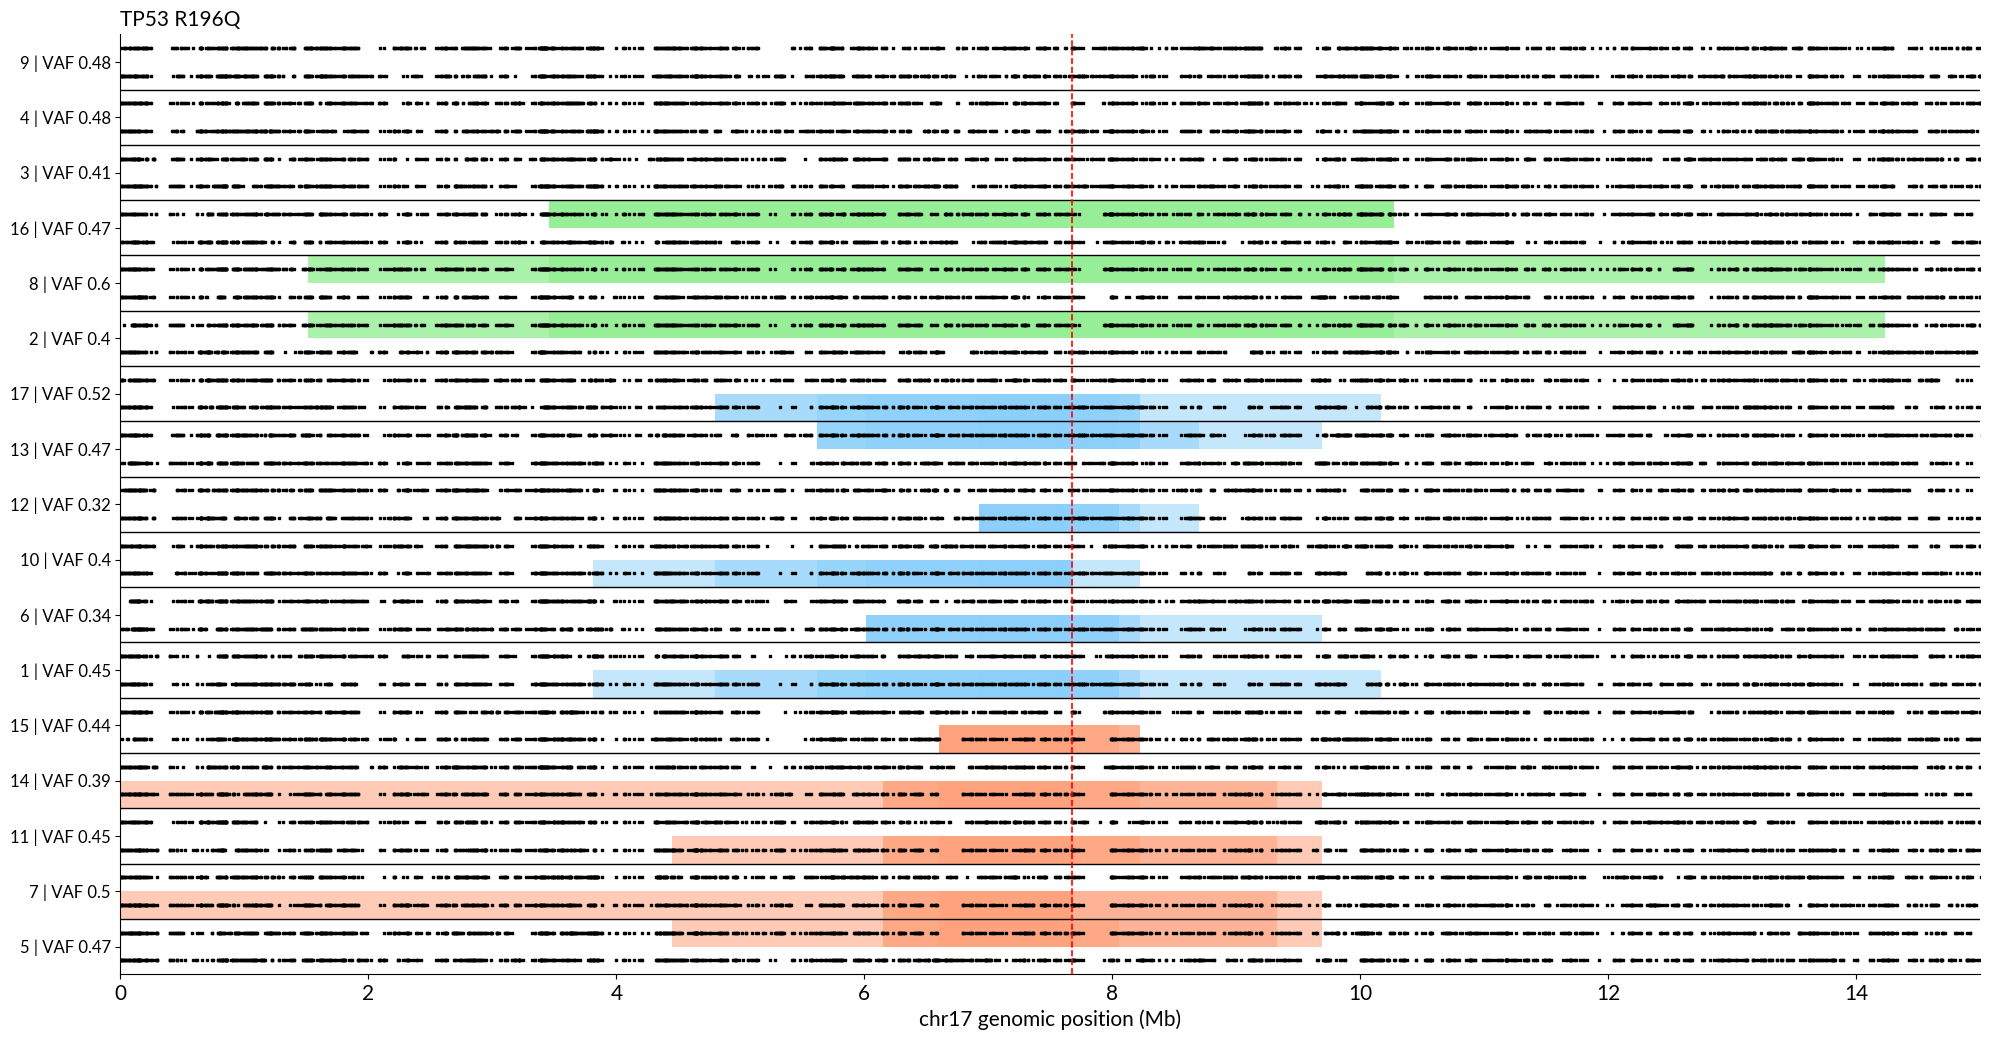

In [10]:
varid = 'R196Q'

in_samples = data_dir+'/chr17_imputed_samples.sample'

hap_matrix, positions = load_qctool_hap_matrix(varid, tmp_dir)
g2_overlapping_segments = get_g2_segments(varid, ukb_tp53_all, output_dir)
g2_overlapping_segments[g2_overlapping_segments.cM > final_minimum_length]
G = build_undirected_graph(g2_overlapping_segments)

hap_block_records = hap_block_records_variants[varid]

fig, ax = plt.subplots(1, 1, figsize=[20, hap_matrix.shape[1]/4 + 2])
ax = plot_hap_groups_anon(ax, varid, in_samples, ukb_tp53_all, hap_block_records)
ax.set_xlim(0, 15)
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/haplotypes_R196Q.png', dpi=300, bbox_inches='tight')
plt.show()

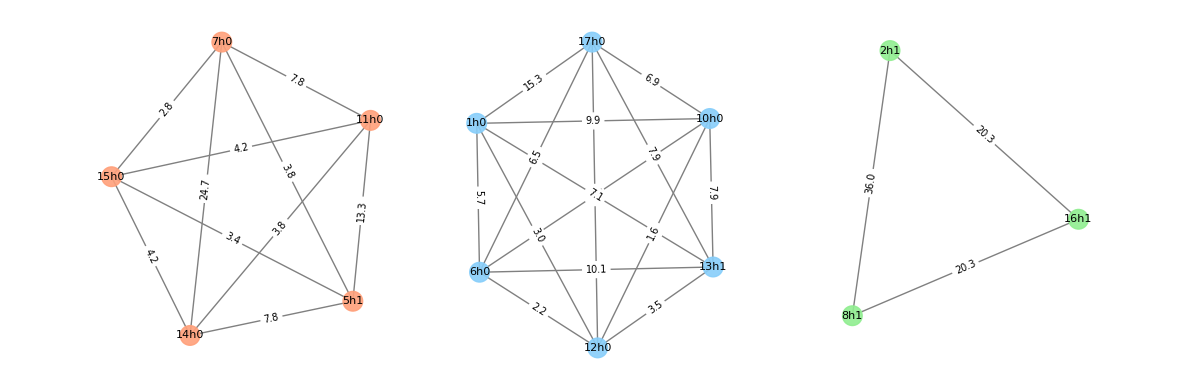

In [11]:
varid = 'R196Q'

hap_matrix, positions = load_qctool_hap_matrix(varid, tmp_dir)
g2_overlapping_segments = get_g2_segments(varid, ukb_tp53_all, output_dir)
g2_overlapping_segments[g2_overlapping_segments.cM > final_minimum_length]
G = build_undirected_graph(g2_overlapping_segments)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_undirected_graph_anon(ax, varid, in_samples, ukb_tp53_all, G)

plt.axis("off")
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/groups_R196Q.pdf')

### Supplementary Fig. 3: Visualisation of haplotype sharing across variants

Pathogenic / likely pathogenic variants

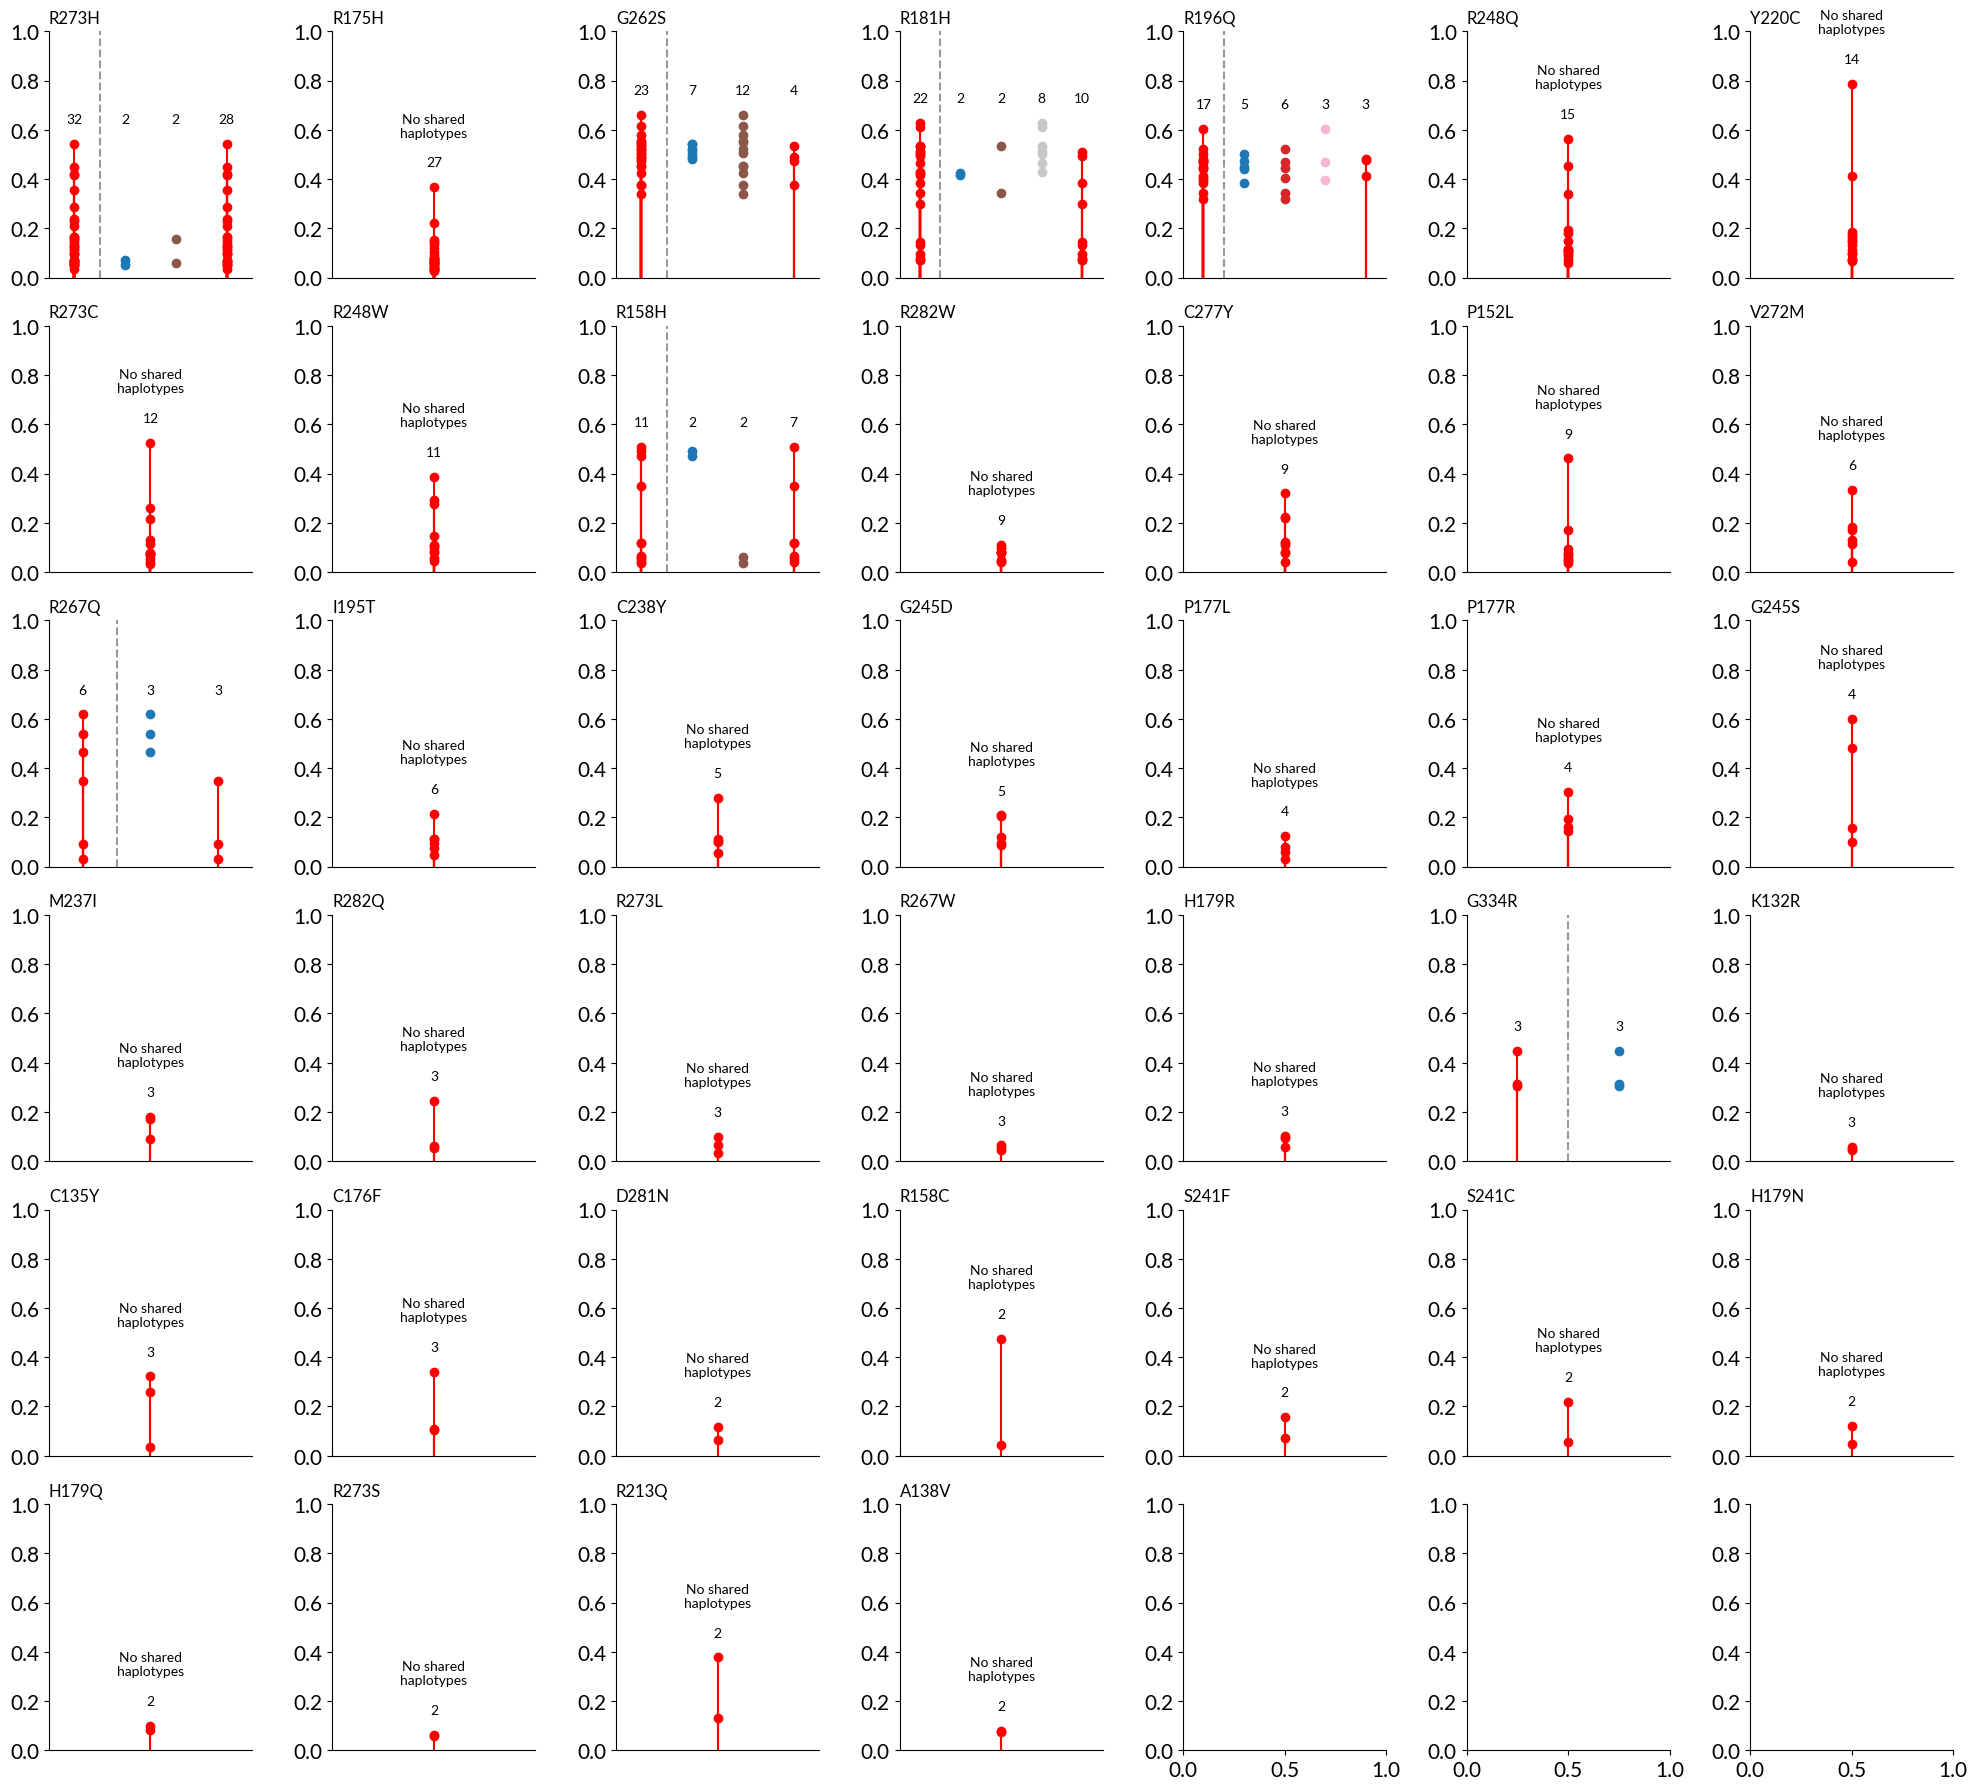

In [12]:
fig, ax = plt.subplots(6, 7, figsize=[20, 18])
ax = ax.ravel()
pathogenicity_categories = ['Pathogenic', 'Likely_Pathogenic']
for i, varid in enumerate(analysis_variants[analysis_variants.pathogenicity.isin(pathogenicity_categories)]['varID']):
    variants = ukb_tp53_all[ukb_tp53_all.varID == varid]
    colour='red'
    m, s, b = ax[i].stem(np.zeros(len(variants)), variants.VAF, linefmt=colour, markerfmt='o', basefmt='white')
    plt.setp(m, 'color', colour)
    ax[i].text(0, variants.VAF.max()+0.1, len(variants), va='center', ha='center')

    ax[i].set_ylim(0, 1)
    ax[i].set_title(varid, loc='left')
    ax[i].set_xticks([])

    variants.loc[variants['minor_group'] == True, 'group_number'] = np.nan

    if variants.group_number.max() == variants.group_number.max():

        n_colours = int(variants.group_number.max()+1)
        cmap = plt.get_cmap('tab20')
        haplo_colour_dict = {i: cmap(i/n_colours) for i in range(n_colours)}

        # Get non-NaN groups and create sequential x-positions
        non_nan_groups = sorted([g for g in variants.group_number.unique() if g == g])
        group_to_xpos = {group: idx + 1 for idx, group in enumerate(non_nan_groups)}
        n_groups = len(non_nan_groups)

        for hg in non_nan_groups:
            df = variants[variants.group_number == hg]
            x_position = group_to_xpos[hg]

            ax[i].scatter(np.zeros(len(df)) + x_position, df.VAF, marker='o', color=haplo_colour_dict[int(hg)])
            if len(df) != 1:
                ax[i].text(x_position, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            else:
                ax[i].text(x_position, variants.VAF.max()+0.1, 'LOH', va='center', ha='center')

        ax[i].vlines(0.5, 0, 1, color='k', ls='dashed', alpha=0.4)

        # Handle ungrouped variants (NaN group_number)
        df = variants[variants.group_number != variants.group_number]
        if len(df) > 0:
            ungrouped_x = n_groups + 1
            m, s, b = ax[i].stem(np.zeros(len(df)) + ungrouped_x, df.VAF, linefmt=colour, markerfmt='o', basefmt='white')
            ax[i].text(ungrouped_x, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            ax[i].set_xlim(-0.5, ungrouped_x + 0.5)
        else:
            ax[i].set_xlim(-0.5, n_groups + 0.5)
    else:
        ax[i].set_xlim(-0.5, 0.5)
        ax[i].text(0, variants.VAF.max()+0.25, 'No shared\nhaplotypes', va='center', ha='center')

plt.tight_layout()
plt.show()

Variants of uncertain significance

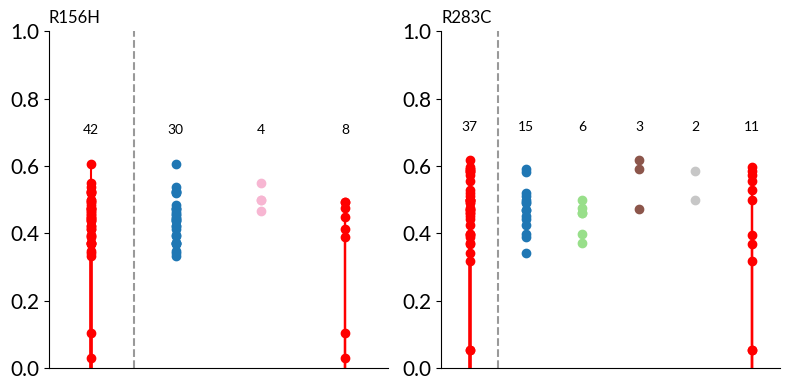

In [13]:
fig, ax = plt.subplots(1, 2, figsize=[8, 4])
ax = ax.ravel()
pathogenicity_categories = ['VUS']
for i, varid in enumerate(analysis_variants[analysis_variants.pathogenicity.isin(pathogenicity_categories)]['varID']):
    variants = ukb_tp53_all[ukb_tp53_all.varID == varid]
    colour='red'
    m, s, b = ax[i].stem(np.zeros(len(variants)), variants.VAF, linefmt=colour, markerfmt='o', basefmt='white')
    plt.setp(m, 'color', colour)
    ax[i].text(0, variants.VAF.max()+0.1, len(variants), va='center', ha='center')

    ax[i].set_ylim(0, 1)
    ax[i].set_title(varid, loc='left')
    ax[i].set_xticks([])

    variants.loc[variants['minor_group'] == True, 'group_number'] = np.nan

    if variants.group_number.max() == variants.group_number.max():

        n_colours = int(variants.group_number.max()+1)
        cmap = plt.get_cmap('tab20')
        haplo_colour_dict = {i: cmap(i/n_colours) for i in range(n_colours)}

        # Get non-NaN groups and create sequential x-positions
        non_nan_groups = sorted([g for g in variants.group_number.unique() if g == g])
        group_to_xpos = {group: idx + 1 for idx, group in enumerate(non_nan_groups)}
        n_groups = len(non_nan_groups)

        for hg in non_nan_groups:
            df = variants[variants.group_number == hg]
            x_position = group_to_xpos[hg]

            ax[i].scatter(np.zeros(len(df)) + x_position, df.VAF, marker='o', color=haplo_colour_dict[int(hg)])
            if len(df) != 1:
                ax[i].text(x_position, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            else:
                ax[i].text(x_position, variants.VAF.max()+0.1, 'LOH', va='center', ha='center')

        ax[i].vlines(0.5, 0, 1, color='k', ls='dashed', alpha=0.4)

        # Handle ungrouped variants (NaN group_number)
        df = variants[variants.group_number != variants.group_number]
        if len(df) > 0:
            ungrouped_x = n_groups + 1
            m, s, b = ax[i].stem(np.zeros(len(df)) + ungrouped_x, df.VAF, linefmt=colour, markerfmt='o', basefmt='white')
            ax[i].text(ungrouped_x, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            ax[i].set_xlim(-0.5, ungrouped_x + 0.5)
        else:
            ax[i].set_xlim(-0.5, n_groups + 0.5)
    else:
        ax[i].set_xlim(-0.5, 0.5)
        ax[i].text(0, variants.VAF.max()+0.25, 'No shared\nhaplotypes', va='center', ha='center')

plt.tight_layout()
plt.show()

Variants for which Fortuno model was not applied

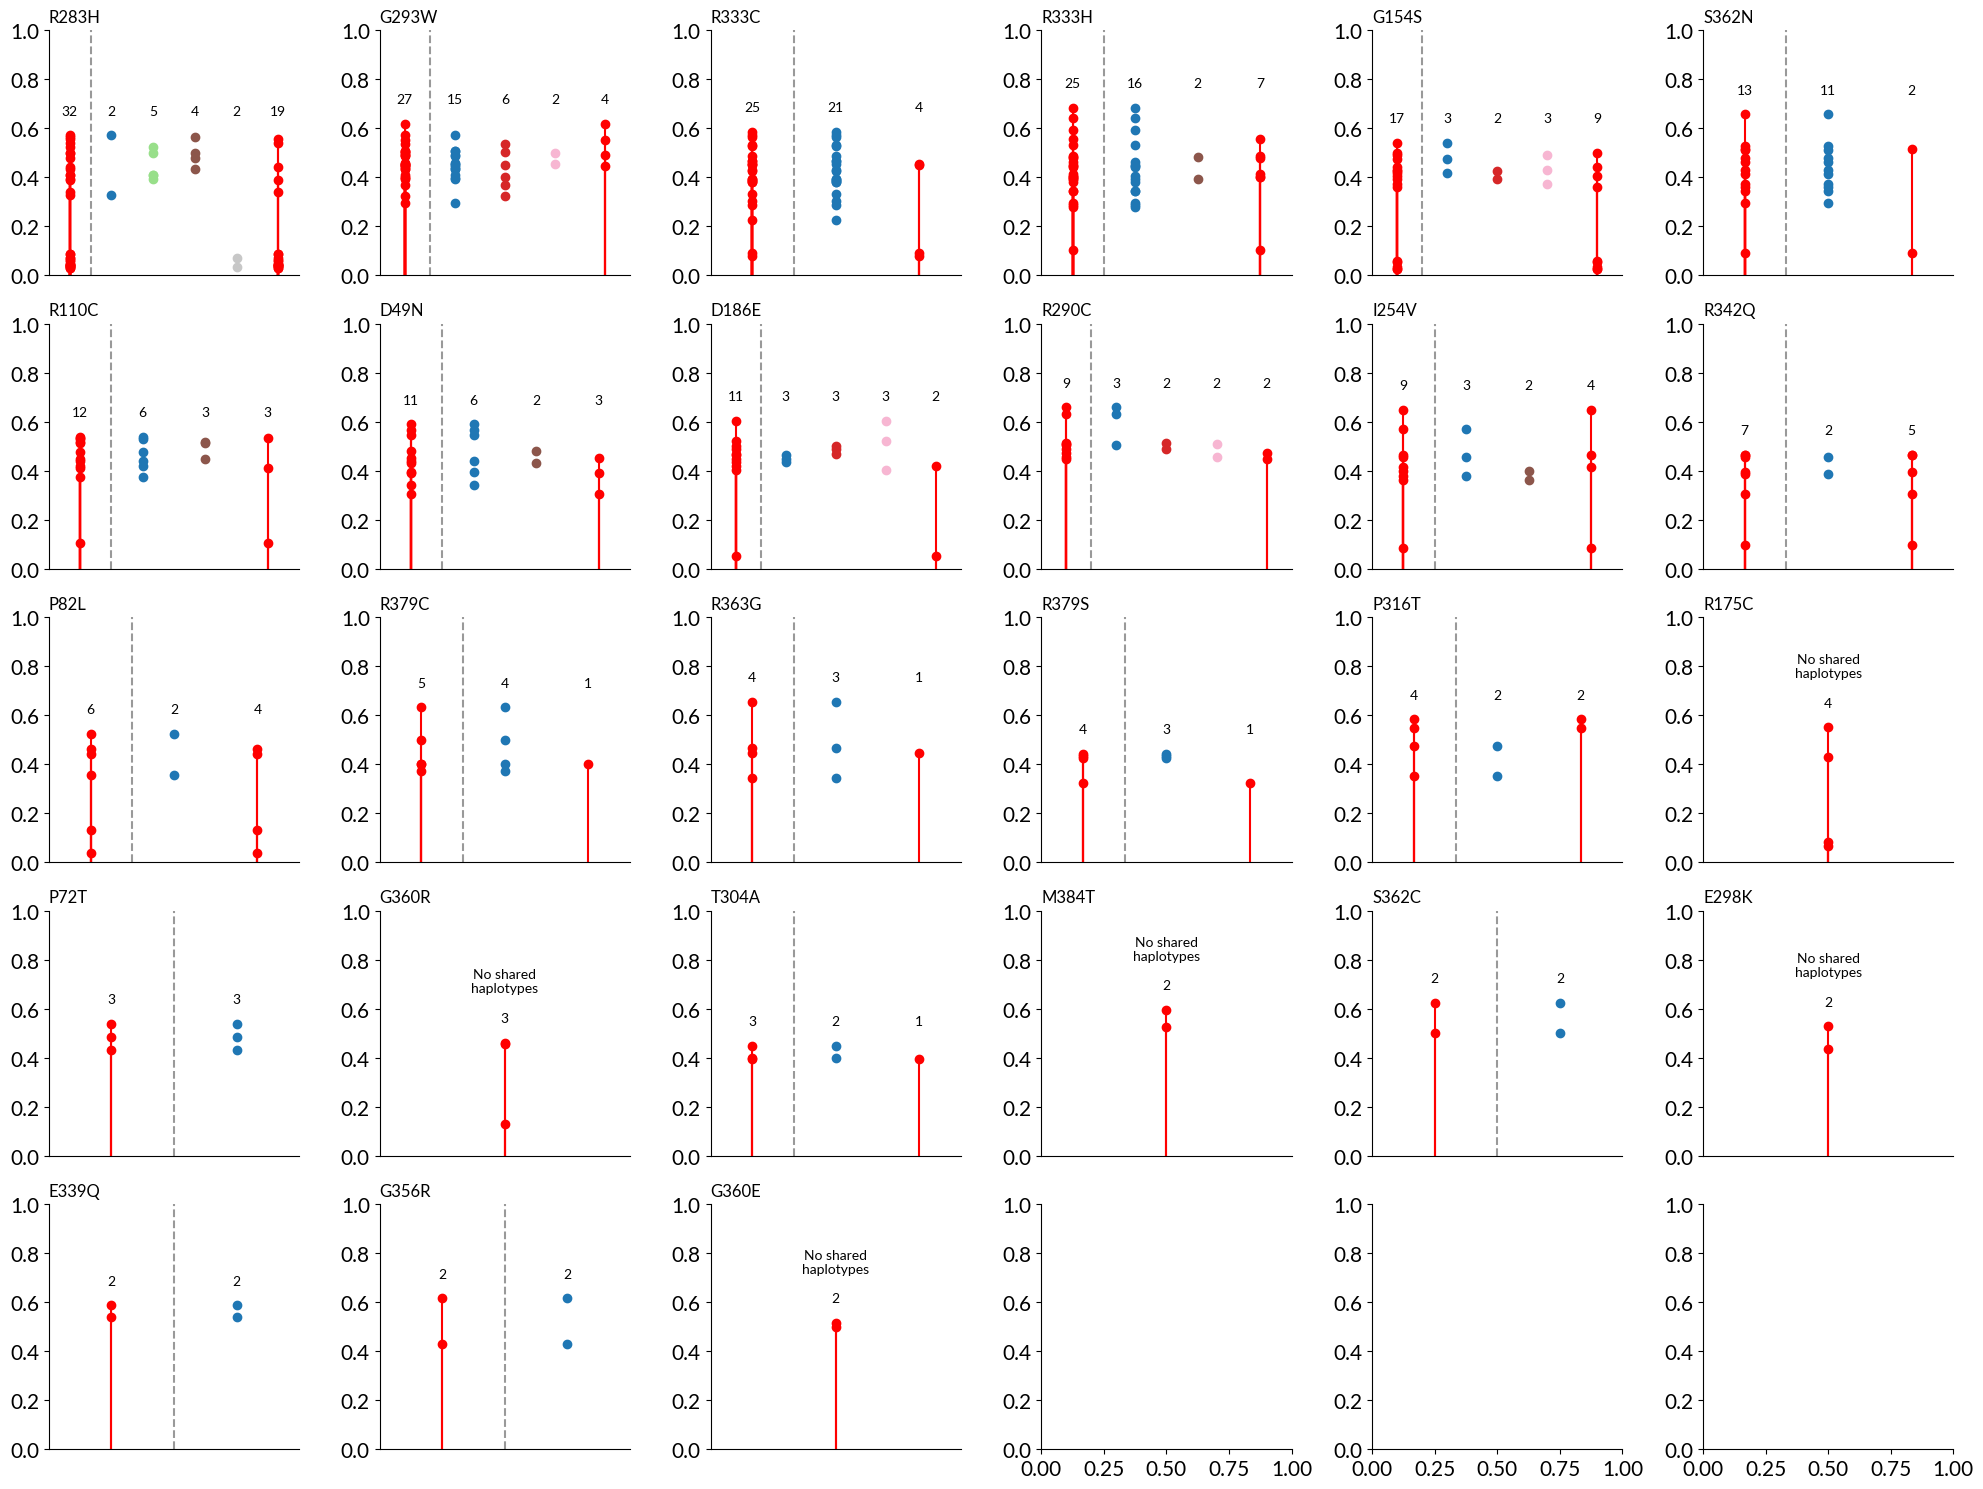

In [14]:
fig, ax = plt.subplots(5, 6, figsize=[20, 15])
ax = ax.ravel()
pathogenicity_categories = ['Model_not_applied']
for i, varid in enumerate(analysis_variants[analysis_variants.pathogenicity.isin(pathogenicity_categories)]['varID']):
    variants = ukb_tp53_all[ukb_tp53_all.varID == varid]
    colour='red'
    m, s, b = ax[i].stem(np.zeros(len(variants)), variants.VAF, linefmt=colour, markerfmt='o', basefmt='white')
    plt.setp(m, 'color', colour)
    ax[i].text(0, variants.VAF.max()+0.1, len(variants), va='center', ha='center')

    ax[i].set_ylim(0, 1)
    ax[i].set_title(varid, loc='left')
    ax[i].set_xticks([])

    variants.loc[variants['minor_group'] == True, 'group_number'] = np.nan

    if variants.group_number.max() == variants.group_number.max():

        n_colours = int(variants.group_number.max()+1)
        cmap = plt.get_cmap('tab20')
        haplo_colour_dict = {i: cmap(i/n_colours) for i in range(n_colours)}

        # Get non-NaN groups and create sequential x-positions
        non_nan_groups = sorted([g for g in variants.group_number.unique() if g == g])
        group_to_xpos = {group: idx + 1 for idx, group in enumerate(non_nan_groups)}
        n_groups = len(non_nan_groups)

        for hg in non_nan_groups:
            df = variants[variants.group_number == hg]
            x_position = group_to_xpos[hg]

            ax[i].scatter(np.zeros(len(df)) + x_position, df.VAF, marker='o', color=haplo_colour_dict[int(hg)])
            if len(df) != 1:
                ax[i].text(x_position, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            else:
                ax[i].text(x_position, variants.VAF.max()+0.1, 'LOH', va='center', ha='center')

        ax[i].vlines(0.5, 0, 1, color='k', ls='dashed', alpha=0.4)

        # Handle ungrouped variants (NaN group_number)
        df = variants[variants.group_number != variants.group_number]
        if len(df) > 0:
            ungrouped_x = n_groups + 1
            m, s, b = ax[i].stem(np.zeros(len(df)) + ungrouped_x, df.VAF, linefmt=colour, markerfmt='o', basefmt='white')
            ax[i].text(ungrouped_x, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            ax[i].set_xlim(-0.5, ungrouped_x + 0.5)
        else:
            ax[i].set_xlim(-0.5, n_groups + 0.5)
    else:
        ax[i].set_xlim(-0.5, 0.5)
        ax[i].text(0, variants.VAF.max()+0.25, 'No shared\nhaplotypes', va='center', ha='center')

plt.tight_layout()
plt.show()

Benign and likely benign variants

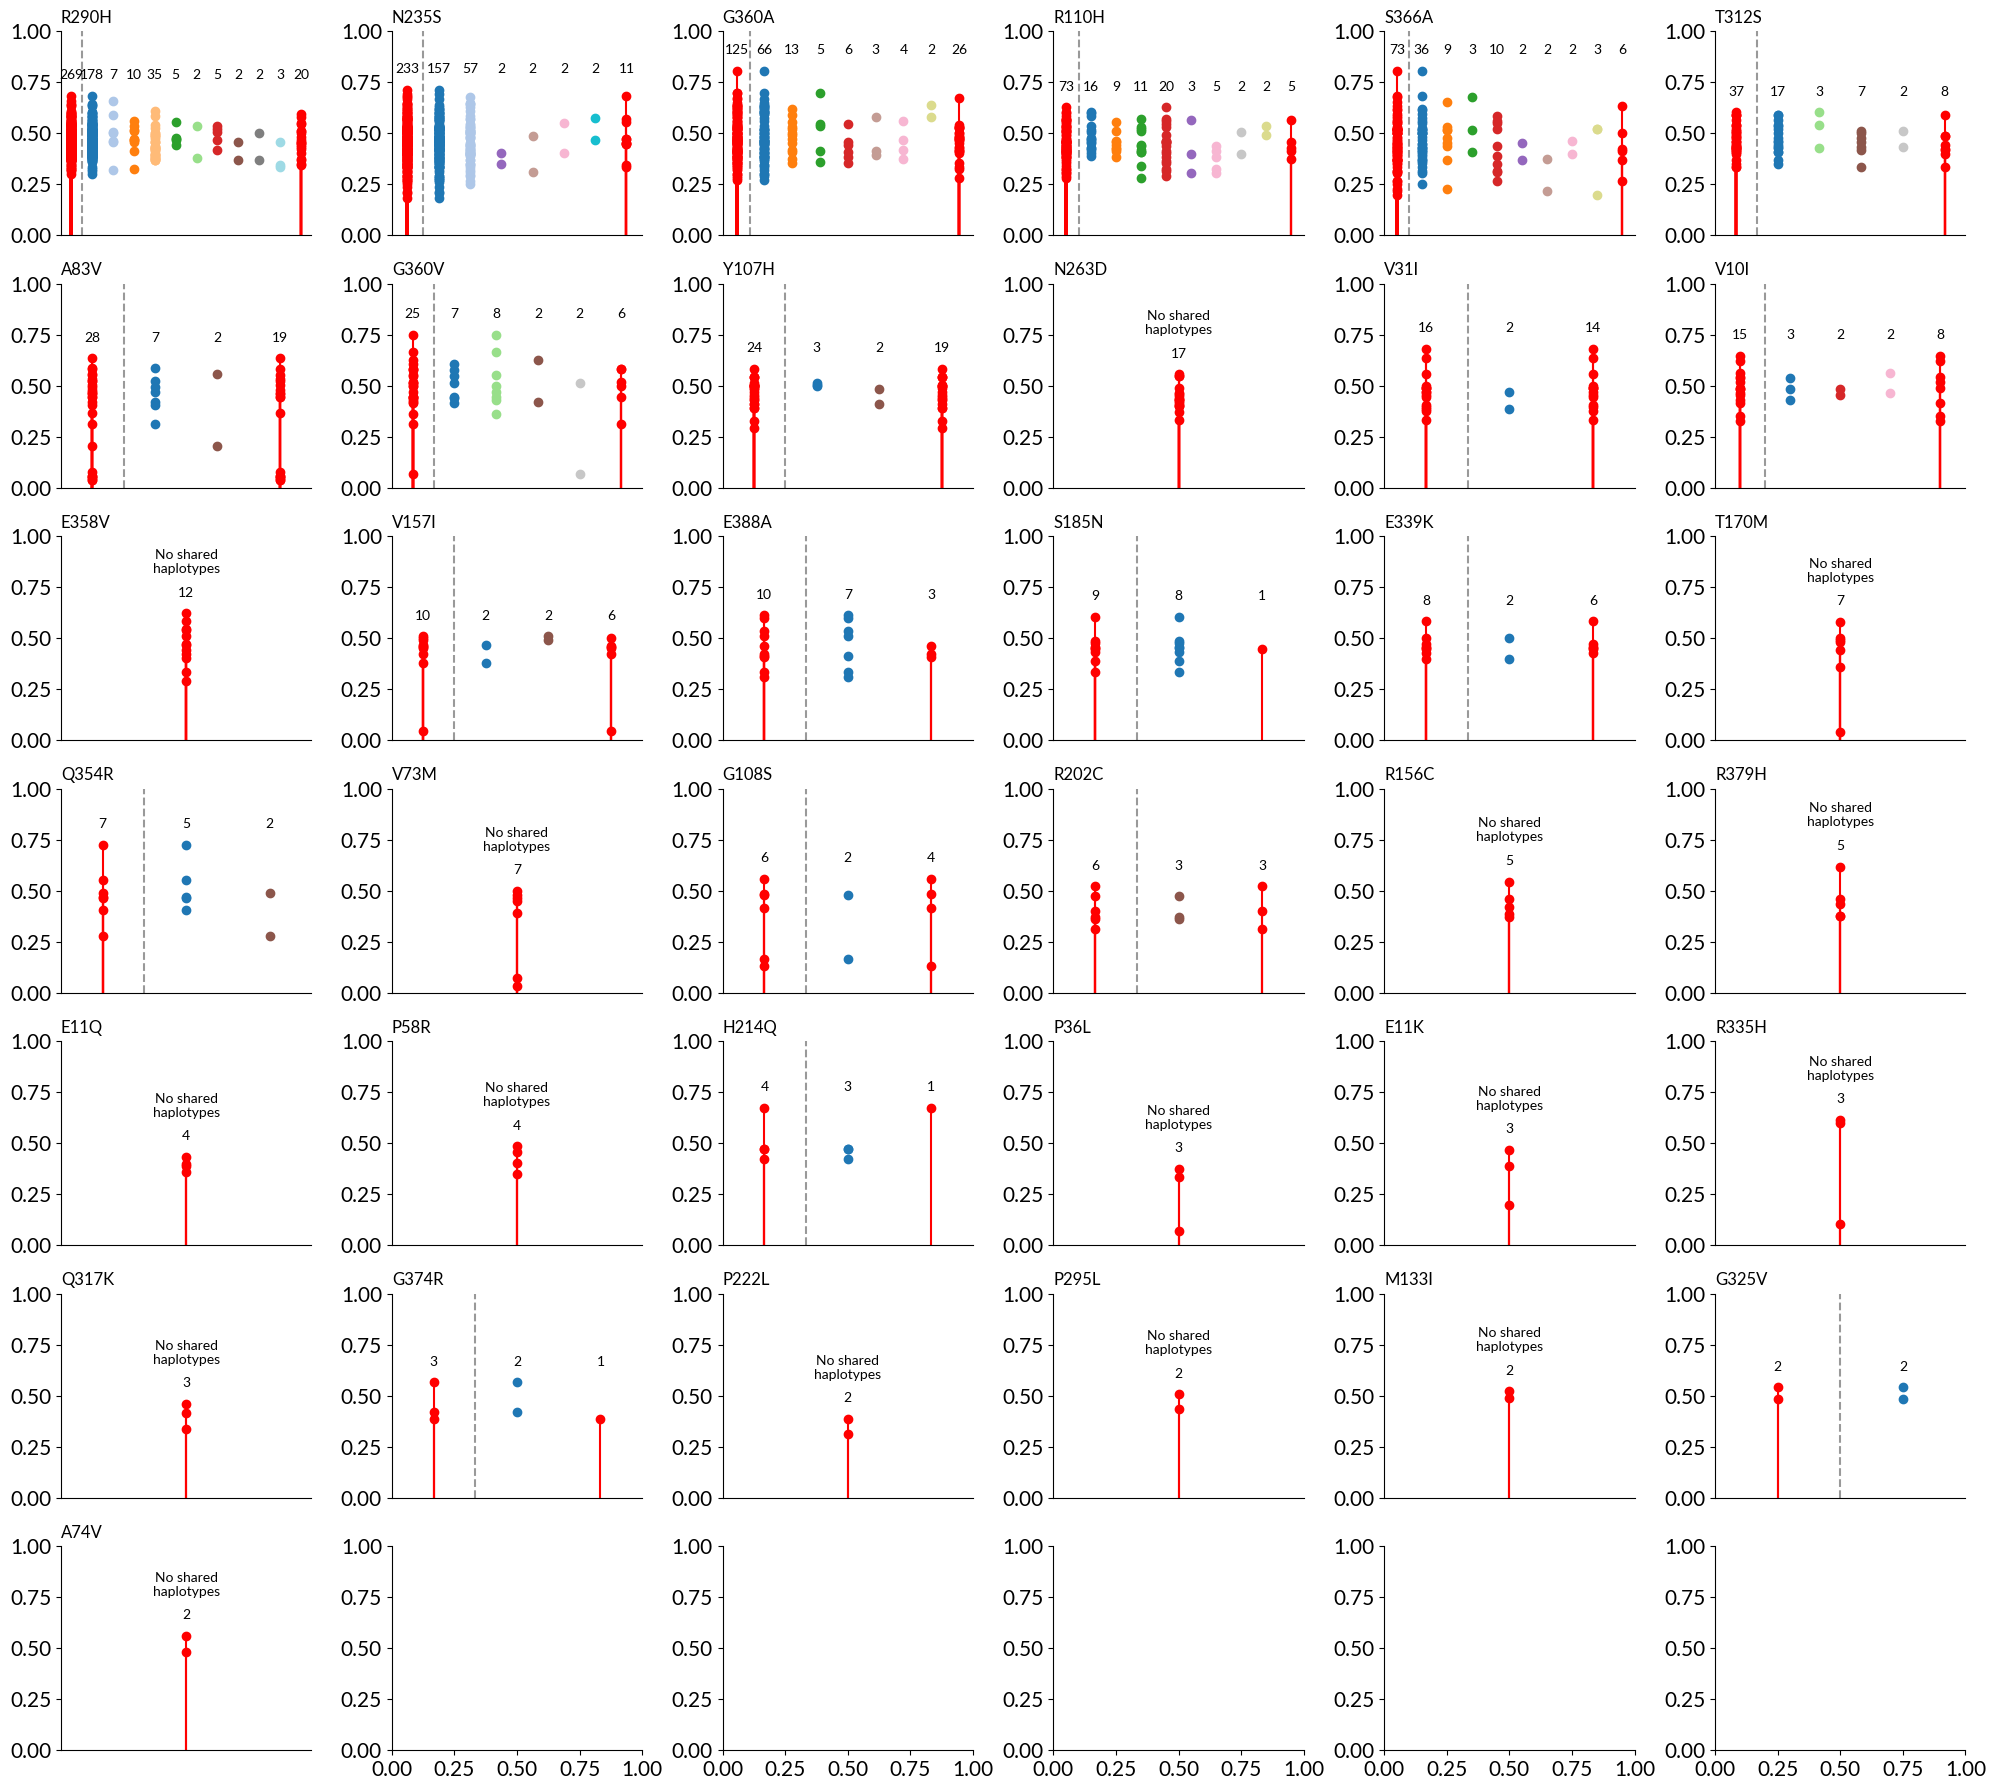

In [15]:
fig, ax = plt.subplots(7, 6, figsize=[20, 18])
ax = ax.ravel()
pathogenicity_categories = ['Benign', 'Likely_Benign']
for i, varid in enumerate(analysis_variants[analysis_variants.pathogenicity.isin(pathogenicity_categories)]['varID']):
    variants = ukb_tp53_all[ukb_tp53_all.varID == varid]
    colour='red'
    m, s, b = ax[i].stem(np.zeros(len(variants)), variants.VAF, linefmt=colour, markerfmt='o', basefmt='white')
    plt.setp(m, 'color', colour)
    ax[i].text(0, variants.VAF.max()+0.1, len(variants), va='center', ha='center')

    ax[i].set_ylim(0, 1)
    ax[i].set_title(varid, loc='left')
    ax[i].set_xticks([])

    variants.loc[variants['minor_group'] == True, 'group_number'] = np.nan

    if variants.group_number.max() == variants.group_number.max():

        n_colours = int(variants.group_number.max()+1)
        cmap = plt.get_cmap('tab20')
        haplo_colour_dict = {i: cmap(i/n_colours) for i in range(n_colours)}

        # Get non-NaN groups and create sequential x-positions
        non_nan_groups = sorted([g for g in variants.group_number.unique() if g == g])
        group_to_xpos = {group: idx + 1 for idx, group in enumerate(non_nan_groups)}
        n_groups = len(non_nan_groups)

        for hg in non_nan_groups:
            df = variants[variants.group_number == hg]
            x_position = group_to_xpos[hg]

            ax[i].scatter(np.zeros(len(df)) + x_position, df.VAF, marker='o', color=haplo_colour_dict[int(hg)])
            if len(df) != 1:
                ax[i].text(x_position, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            else:
                ax[i].text(x_position, variants.VAF.max()+0.1, 'LOH', va='center', ha='center')

        ax[i].vlines(0.5, 0, 1, color='k', ls='dashed', alpha=0.4)

        # Handle ungrouped variants (NaN group_number)
        df = variants[variants.group_number != variants.group_number]
        if len(df) > 0:
            ungrouped_x = n_groups + 1
            m, s, b = ax[i].stem(np.zeros(len(df)) + ungrouped_x, df.VAF, linefmt=colour, markerfmt='o', basefmt='white')
            ax[i].text(ungrouped_x, variants.VAF.max()+0.1, len(df), va='center', ha='center')
            ax[i].set_xlim(-0.5, ungrouped_x + 0.5)
        else:
            ax[i].set_xlim(-0.5, n_groups + 0.5)
    else:
        ax[i].set_xlim(-0.5, 0.5)
        ax[i].text(0, variants.VAF.max()+0.25, 'No shared\nhaplotypes', va='center', ha='center')

plt.tight_layout()
plt.show()

# Save results

In [18]:
ukb_tp53_all_tosave = ukb_tp53_all.drop('ID_v0', axis=1)
ukb_tp53_all_tosave['binomial_p_value'] = stats.binom.cdf(ukb_tp53_all_tosave['var_depth'], ukb_tp53_all_tosave['depth'], 0.46)
# haplotype classifier
#ukb_tp53_plp = pd.merge(ukb_tp53_plp, all_variants_haplo_groups[['ID_v0', 'Protein_change_abbreviated_P04637', 'haplo_group']], on=['ID_v0', 'Protein_change_abbreviated_P04637'], how='left')

#ukb_tp53_plp['haplo_group'] = ukb_tp53_plp['haplo_group'].replace(np.nan, 0)

# assign any variant with a major group assignment as 'likely germline'
ukb_tp53_all_tosave['germ_likelihood'] = np.where(ukb_tp53_all_tosave['binomial_p_value'] < 0.01, 'unlikely',
                                           np.where((ukb_tp53_all_tosave['group_number'] == ukb_tp53_all_tosave['group_number']) &
                                                    (ukb_tp53_all_tosave['minor_group'] == False), 'likely', 'inconclusive'))

# save this version 
ukb_tp53_all.to_csv('results/ukb_tp53_variants_haplo_annotated.tsv', index=False, sep='\t') # original name ukb_tp53_all_haplo_groups_annotated_2025-11-05.before_manual_assignment.tsv